<a href="https://colab.research.google.com/github/vencov/FAV_course/blob/main/TutCochModels/EX_GammatoneFiltebank.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gammatone (GT) basilar-membrane model: input/output functions

Python port of the gammatone model implementaion


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.signal import lfilter


# ---------------------------------------------------------------------------
# gammaf1.m  - digital gammatone filter transfer function
# ---------------------------------------------------------------------------
def gammaf1(fs, f0, beta, n, ftype):
    """Digital gammatone filter (n-th order) as complex-coefficient IIR.
    ftype = 1: bilinear transform, 2: impulse invariance."""
    if ftype == 1:                                  # bilinear transform
        w0 = 2 * np.pi * f0 / fs
        W0 = np.tan(w0 / 2)                         # prewarping
        Beta = np.tan(np.pi * beta / fs)
        tmp = 1 + 1 / Beta - 1j * W0 / Beta
        b = np.array([1, 1], dtype=complex) / tmp
        a = np.array([tmp, 1 - 1 / Beta - 1j * W0 / Beta]) / tmp
    elif ftype == 2:                                # impulse invariance
        b = np.array([1 - np.exp(-2 * np.pi * beta / fs)], dtype=complex)
        a = np.array([1, -np.exp(-(2 * np.pi * beta + 1j * 2 * np.pi * f0) / fs)])
    else:
        raise ValueError("ftype must be 1 or 2")

    b2 = np.array([1.0 + 0j])
    a2 = np.array([1.0 + 0j])
    for _ in range(n):                              # cascade n identical 1st-order sections
        b2 = np.convolve(b, b2)
        a2 = np.convolve(a, a2)
    return b2, a2


# ---------------------------------------------------------------------------
# getGFBFilterCoefs.m - coefficients of a 4th-order gammatone filterbank
# ---------------------------------------------------------------------------
def getGFBFilterCoefs(fs, centerfreq, bw):
    centerfreq = np.atleast_1d(centerfreq)
    beta = 1.0183 * np.atleast_1d(bw)               # 4th order gamma (0.637 if 2nd order)
    b, a = [], []
    for k in range(len(centerfreq)):
        bt, at = gammaf1(fs, centerfreq[k], beta[k], 4, 2)
        b.append(bt)
        a.append(at)
    return np.vstack(b), np.vstack(a)


# ---------------------------------------------------------------------------
# initBMGTpar.m - initialise parameters of the gammatone BM model
# ---------------------------------------------------------------------------
class BMParams:
    """Container replacing the MATLAB struct CBM."""
    pass


def initBMGTpar(cfArray, fs):
    cfArray = np.asarray(cfArray, dtype=float)
    bandwidth = 24.7 + cfArray / 9.265              # ERB (Glasberg & Moore)
    CBM = BMParams()
    CBM.GT_b, CBM.GT_a = getGFBFilterCoefs(fs, cfArray, bandwidth)
    CBM.bandwidth = bandwidth
    CBM.cfArray = cfArray
    pastVal = None                                  # MATLAB: [] (no filter state)
    return CBM, pastVal


# ---------------------------------------------------------------------------
# fce_BMgammatone.m - filter the signal with the gammatone filterbank
# ---------------------------------------------------------------------------
def fce_BMgammatone(signal, par, pastGTn=None):
    """Returns out (len(signal) x nsect, highest CF in first column, as in
    the Nobili model) and the final filter states pastGTn (order x nsect)."""
    signal = np.asarray(signal).ravel()
    nsect = len(par.cfArray)
    out = np.zeros((len(signal), nsect))
    order = par.GT_a.shape[1] - 1

    if pastGTn is None or np.size(pastGTn) == 0:
        pastGTn = np.zeros((order, nsect), dtype=complex)

    for ch in range(nsect):
        outBM, pastGTn[:, ch] = lfilter(par.GT_b[ch], par.GT_a[ch], signal,
                                        zi=pastGTn[:, ch])
        out[:, ch] = 2 * np.real(outBM)

    out = out[:, ::-1]                              # fliplr: highest freq at lowest section
    return out, pastGTn


# ---------------------------------------------------------------------------
# gaussgrid.m - grid on 0-1 with Gaussian-distributed density
# ---------------------------------------------------------------------------
def gaussgrid(N=500, plotflag=0):
    """BM site array with Gaussian-distributed spacing (fractional distance from stapes)."""
    stred = 0.35
    sig1 = 2 * 1.2 ** 2
    sig2 = 2 * 0.46 ** 2

    xo = np.arange(1, N + 1) / N
    ind = int(np.ceil(stred / xo[0]))               # MATLAB 1-based count
    dx = np.empty(N)
    dx[:ind] = np.exp((xo[:ind] - xo[ind - 1]) ** 2 / sig1)
    dx[ind:] = np.exp((xo[ind:] - xo[ind - 1]) ** 2 / sig2)
    dx = dx / dx.sum()

    x = np.cumsum(dx)
    if x[-1] > 1:
        x[-1] = 1

    if plotflag == 1:
        dens = 1 / dx
        Nmx, Nmn = dens.max(), dens.min()
        Nmdl = dens[np.argmin(np.abs(x - 0.5))]
        plt.figure(22)
        plt.clf()
        plt.plot(x, dens, '-r')
        plt.axis([0, 1, 0, Nmx])
        plt.text(0.2, 0.95 * Nmx, f'Max.density = {Nmx:.4g}')
        plt.text(0.2, 0.85 * Nmx, f'Mid.density = {Nmdl:.4g}')
        plt.text(0.2, 0.75 * Nmx, f'Min.density = {Nmn:.4g}')
        plt.ylabel('Point density')
        plt.xlabel('Fractional distance from stapes')
        plt.show()
    return x



  # Values taken from fce_DRNLjepsen/cf_nobiliEXP_R3107_10dBOME.mat ('cf_new'),
# base (high CF) -> apex (low CF), 300 channels in order to get very fine freq resolution
cf_new = np.array([
    18737.739830, 18512.897404, 18288.054979, 18063.212554, 17838.370129, 17613.527703,
    17388.685278, 17163.842853, 16939.000428, 16714.158002, 16489.315577, 16264.473152,
    15826.723294, 15613.657479, 15400.591664, 15193.180785, 14985.769906, 14783.863876,
    14581.957846, 14188.863279, 13997.532516, 13806.201753, 13619.949060, 13433.696368,
    13252.386969, 13071.077571, 12894.580267, 12718.082964, 12546.270039, 12374.457114,
    12207.204241, 12039.951367, 11877.137517, 11714.323667, 11555.831026, 11397.338385,
    11243.052265, 11088.766144, 10938.574899, 10788.383655, 10642.178605, 10495.973555,
    10401.090454, 10306.207353, 10211.324251, 10072.777008, 9934.229766, 9799.359677,
    9664.489588, 9533.199058, 9401.908528, 9274.102552, 9146.296577, 9021.882674,
    8897.468771, 8776.356911, 8655.245052, 8537.347597, 8419.450142, 8304.681779,
    8189.913417, 8078.191097, 7966.468778, 7857.711657, 7748.954537, 7643.083917,
    7537.213296, 7434.152566, 7331.091836, 7230.766420, 7130.441003, 7032.778303,
    6935.115602, 6840.044948, 6744.974293, 6652.426888, 6559.879484, 6499.818736,
    6439.757987, 6379.697238, 6291.997206, 6204.297173, 6118.924768, 6033.552364,
    5950.445810, 5867.339257, 5786.438418, 5705.537578, 5626.783912, 5548.030245,
    5471.366762, 5394.703280, 5320.074508, 5245.445735, 5172.797670, 5100.149604,
    5029.429675, 4958.709747, 4889.866781, 4821.023816, 4776.346604, 4731.669391,
    4686.992179, 4621.755013, 4556.517848, 4493.012128, 4429.506409, 4367.686181,
    4305.865954, 4245.686485, 4185.507015, 4126.924757, 4068.342498, 4011.315059,
    3954.287620, 3898.773735, 3843.259849, 3789.219346, 3735.178843, 3682.572618,
    3629.966393, 3578.756378, 3527.546364, 3494.312458, 3461.078551, 3427.844644,
    3379.316866, 3330.789087, 3283.549275, 3236.309462, 3190.323431, 3144.337401,
    3099.571876, 3054.806351, 3011.228938, 2967.651526, 2925.230692, 2882.809859,
    2841.514908, 2800.219958, 2760.021008, 2719.822057, 2680.690019, 2641.557981,
    2603.464539, 2565.371096, 2528.288684, 2491.206271, 2455.108055, 2419.009839,
    2383.869699, 2348.729558, 2314.522065, 2280.314571, 2247.014972, 2213.715372,
    2181.299571, 2148.883769, 2117.328309, 2085.772848, 2055.054895, 2024.336941,
    1994.434266, 1964.531592, 1935.422558, 1906.313523, 1877.977066, 1849.640609,
    1822.056224, 1794.471839, 1767.619565, 1740.767291, 1714.627698, 1688.488105,
    1663.042278, 1637.596450, 1612.825975, 1588.055500, 1563.942453, 1539.829406,
    1516.356339, 1492.883271, 1470.033197, 1447.183123, 1424.939509, 1402.695894,
    1359.389391, 1338.310834, 1317.232277, 1296.713161, 1276.194046, 1256.219524,
    1236.245002, 1216.800620, 1197.356238, 1178.427925, 1159.499612, 1141.073672,
    1122.647731, 1104.710830, 1086.773928, 1051.852245, 1034.854828, 1017.857410,
    1001.311118, 984.764826, 968.657685, 952.550545, 936.870901, 921.191256,
    890.664268, 875.805879, 860.947490, 846.483455, 832.019420, 817.939271,
    803.859123, 790.152673, 776.446223, 749.760882, 736.772337, 723.783792,
    711.139974, 698.496155, 686.187913, 673.879671, 649.916529, 638.252958,
    626.589387, 615.235377, 603.881366, 581.776034, 571.016715, 560.257395,
    549.783637, 539.309878, 529.114101, 518.918325, 499.067979, 489.406228,
    479.744478, 460.933837, 442.622446, 433.709750, 424.797053, 407.444761,
    398.998887, 390.553012, 374.109584, 358.102577, 350.311493, 342.520409,
    327.351805, 312.585786, 305.398728, 298.211670, 284.219054, 277.408434,
    270.597814, 257.338091, 244.430293, 238.147685, 231.865077, 219.633353,
    207.726268, 201.930737, 196.135206, 184.851781, 173.867826, 168.521610,
    163.175395, 152.766749, 142.634356, 137.702621, 132.770886, 123.169200,
    113.822350, 104.723573, 95.866284, 87.244076, 83.047391, 78.850707,
    70.680105, 66.703231, 62.726357, 54.983708, 51.215132, 47.446556,
    42.620059, 37.793563, 32.967067, 26.014253, 19.061439, 12.108626,
    5.155812, 5, 4.5, 4.4, 4.3, 4,
])


CF_full = cf_new[::-1]  # low -> high, as drnl() expects (MATLAB: fliplr(cf_new))
print(f"{len(CF_full)} channels, CF range: {CF_full[0]:.1f}-{CF_full[-1]:.1f} Hz")


300 channels, CF range: 4.0-18737.7 Hz


---
## 1. Input/output function

Drives a single CF region with a 1 kHz tone at levels from 0-100 dB SPL and
tracks the BM displacement at the best-excited channel, showing that the growth of the GT filter is linear.

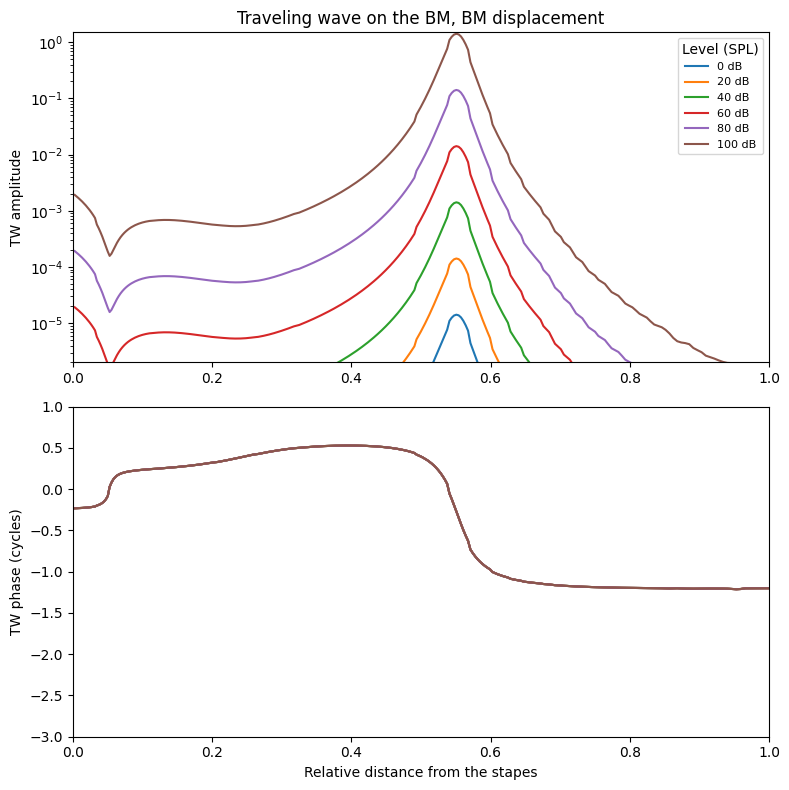

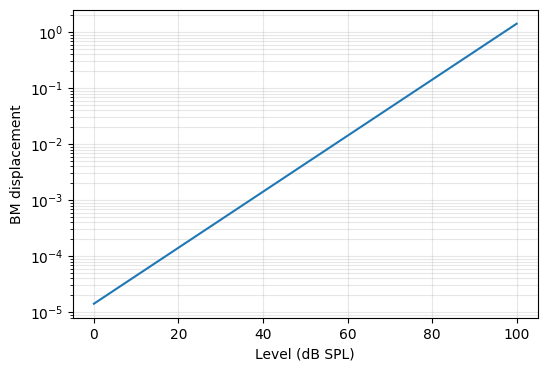

In [5]:
# ===== input/output functions of the gammatone (GT) BM model =====
fs = 40e3                                   # sampling rate in Hz
mat_file = 'fce_GTmodel/cf_nobiliEXP_R3107_10dBOME.mat'   # adjust if needed

# --- tone parameters
freq = 1e3                                  # tone frequency
Lvect = np.arange(0, 101, 20)               # levels in dB SPL (0:20:100)

# --- CFs of the model (Nobili model with 300 sections)

CF = CF_full

# --- initialisation of the GT model
CBM, pastVal = initBMGTpar(CF, fs)

# --- stimulus
plotflagTW = True
Rdur = 10e-3                                # raised-cosine onset ramp duration
Tonset = 30e-3                              # onset time (steady state afterwards)
Nper = 30                                   # number of periods
Nonset = int(round(Tonset * fs))            # onset samples
Nstat = int(round(fs * Nper / freq))        # samples in the analysed steady-state part
Tdur = (Nonset + Nstat) / fs                # signal duration

tx = np.arange(int(round(Tdur * fs)) + 1) / fs           # 0:1/fs:Tdur
sigIn = np.sqrt(2) * np.sin(2 * np.pi * freq * tx)

xr = np.arange(int(round(Rdur * fs)) + 1) / fs           # 0:1/fs:Rdur
rampUp = (1 + np.cos(np.pi * xr / Rdur + np.pi)) / 2     # raised-cosine onset
wholeramp = np.concatenate([rampUp, np.ones(len(sigIn) - len(xr))])
sigIn = sigIn * wholeramp

idxFreq = int(round(freq * Nstat / fs))     # index of freq component in the BM spectrum
IO = np.zeros(len(Lvect), dtype=complex)
x = gaussgrid(len(CF), 0)                   # relative distance from the stapes

fig1, (ax_amp, ax_ph) = plt.subplots(2, 1, figsize=(8, 8), num=1)

for k, Lin in enumerate(Lvect):
    sigInLin = sigIn * 10 ** (Lin / 20) * 2e-5          # scale to dB SPL (re 20 uPa)

    # --- model
    sigOutBM, _ = fce_BMgammatone(sigInLin, CBM, pastVal)
    seg = sigOutBM[Nonset - 1:Nonset - 1 + Nstat, :]     # steady-state part
    SpectBM = np.fft.fft(seg, axis=0) / Nstat * np.exp(-1j * 2 * np.pi * freq * Nstat / fs)
    ExcPatBM = SpectBM[idxFreq, :]
    if k == 0:                                           # for the lowest intensity
        idxExc = np.argmax(np.abs(ExcPatBM))
    IO[k] = ExcPatBM[idxExc]

    # --- plot BM travelling wave
    if plotflagTW:
        ax_amp.plot(x, np.abs(ExcPatBM), label=f'{Lin} dB')
        ax_ph.plot(x, np.unwrap(np.angle(ExcPatBM)) / (2 * np.pi))

ax_amp.set_yscale('log'); ax_amp.set_ylim(2e-6, 1.5); ax_amp.set_xlim(0, 1)
ax_amp.set_ylabel('TW amplitude')
ax_amp.set_title('Traveling wave on the BM, BM displacement')
ax_amp.legend(title='Level (SPL)', fontsize=8)
ax_ph.set_xlim(0, 1); ax_ph.set_ylim(-3, 1)
ax_ph.set_xlabel('Relative distance from the stapes')
ax_ph.set_ylabel('TW phase (cycles)')
fig1.tight_layout()

# --- plot the I/O function
fig2, ax = plt.subplots(figsize=(6, 4), num=2)
ax.semilogy(Lvect, np.abs(IO))
ax.set_ylabel('BM displacement')
ax.set_xlabel('Level (dB SPL)')
ax.grid(True, which='both', alpha=0.3)
plt.show()